# Analisi Competitor: Mercato delle Calzature

## 1. Introduzione e Obiettivi dell'Analisi

Questo notebook documenta il processo di analisi esplorativa e comparativa tra il nostro brand e i principali competitor selezionati (Azienda C e Azienda NG). 
L'obiettivo richiesto dal CEO è identificare i punti di forza, le debolezze e le opportunità di mercato in vista della prossima stagione.

Le metriche chiave analizzate includono:
* Ampiezza dell'assortimento (volumi per macro e micro-categorie).
* Posizionamento di prezzo (prezzo medio, minimo, massimo per tipologia).
* Gap di offerta (identificazione di nicchie scoperte).
* Strategie promozionali e di sconto (dati aggregati).
* Distribuzione dei prezzi reali su retailer.
* Sconti per macro-cadegoria e Brand
* Varietà dell'offerta cromatica (Bonus).
* Confronto Canale: Sito ufficiale vs Piattaforma Z

---
## 2. Importazione Librerie e Preparazione dei Dati

In questa fase importiamo le librerie necessarie (Pandas, Matplotlib, NumPy) e carichiamo i dataset precedentemente puliti. 
Poiché i dati provengono da fonti o estrazioni diverse, è fondamentale standardizzare i nomi delle colonne chiave (es. Brand, Scarpe, Macro_categoria, Prezzo_reale) per poter concatenare le informazioni in un unico dataframe unificato. Questo ci permetterà di creare visualizzazioni comparative in modo efficiente.

In [1]:
from Library import *

df_G  = pd.read_csv("Azienda_G_clean.csv")
df_C  = pd.read_csv("Azienda_C_clean.csv")
df_NG = pd.read_csv("Azienda_NG_modelli.csv")  # solo modelli unici
df_Z  = pd.read_csv("Azienda_Z_clean.csv")
display(df_G.head(3))
display(df_C.head(3))
display(df_NG.head(3))
display(df_Z.head(3))

,Scarpe,Prezzo,Categoria,Macro_categoria,Micro_categoria,Brand
0,Spherica Plus Uomo,119.9,Sneaker slip in,Sneakers,Sneakers slip-in,G
1,Spherica Plus Uomo,109.9,Sneaker slip in,Sneakers,Sneakers slip-in,G
2,Wells Uomo,109.9,Sneakers basse,Sneakers,Sneakers basse,G


,Scarpe,Categoria,Prezzo reale,Prezzo scontato,Materiale,In sconto,Materiale_pulito,Macro_categoria,Micro_categoria,Brand
0,Torhill Lo,Scarpe da uomo,120.0,120.0,Cola scamosciata,False,Non specificato,Scarpe eleganti,Stringate / Derby,C
1,Godney Boat,Scarpe Originals da Uomo,130.0,130.0,Pelle marrone chiaro britannica,False,Pelle,Scarpe eleganti,Stringate / Derby,C
2,Berwick Seam,Scarpe da uomo,85.0,85.0,Pelle nera,False,Pelle,Scarpe eleganti,Stringate / Derby,C


,Scarpe,Prezzo,Materiale,Tipo,Sottotipo,Macro_categoria,Micro_categoria,Brand
0,Men's Leather Loafers,139.5,Leather,Loafers,Leather Loafers,Mocassini,Mocassini,NG
1,Men's Patent Oxford Shoes,149.5,Patent,Oxford Shoes,Patent Oxford Shoes,Scarpe eleganti,Stringate / Derby,NG
2,Men's Leather Derbys,149.5,Leather,Derby Shoes,Leather Derby Shoes,Scarpe eleganti,Stringate / Derby,NG


,Brand,Scarpe,Categoria,Prezzo reale,Prezzo scontato,In sconto,Dettaglio/Colore,Macro_categoria,Micro_categoria
0,G,Spherica,Sneakers basse,99.99,89.99,True,black,Sneakers,Sneakers basse
1,G,Spherica Actif X4,Sneakers basse,89.99,89.99,False,navy,Sneakers,Sneakers basse
2,C,Swift,Sneakers basse,119.99,101.99,True,black,Sneakers,Sneakers basse


In [2]:
#standardizziamo le colonne
df_G  = df_G.rename(columns={"Prezzo": "Prezzo_reale"})
df_NG = df_NG.rename(columns={"Prezzo": "Prezzo_reale"})
df_C  = df_C.rename(columns={"Prezzo reale": "Prezzo_reale","Prezzo scontato": "Prezzo_scontato"})

In [3]:
COLONNE = ["Brand", "Scarpe", "Macro_categoria", "Micro_categoria", "Prezzo_reale"] #utili per il confronto

df_unificato = pd.concat([df_G[COLONNE],df_C[COLONNE],df_NG[COLONNE],], ignore_index=True)
display(df_unificato)

,Brand,Scarpe,Macro_categoria,Micro_categoria,Prezzo_reale
0,G,Spherica Plus Uomo,Sneakers,Sneakers slip-in,119.9
1,G,Spherica Plus Uomo,Sneakers,Sneakers slip-in,109.9
2,G,Wells Uomo,Sneakers,Sneakers basse,109.9
3,G,Spherica Uomo,Sneakers,Sneakers basse,99.9
4,G,Pantelleria Uomo,Ciabatte & Pantofole,Espadrillas,89.9
...,...,...,...,...,...
504,NG,Men's Suede Chelsea Boots,Stivali & Stivaletti,Stivaletti,159.5
505,NG,Men's Suede Desert Boots,Stivali & Stivaletti,Stivaletti,139.5
506,NG,Men's Suede Chelsea Boots,Stivali & Stivaletti,Stivaletti,155.0
507,NG,"Men's Suede, Leather And Canvas Sneakers",Sneakers,Sneakers basse,149.5


In [4]:
COLORI = {"G": "blue", "C": "orange", "NG": "green"}

print("--- Dataset unificato ---")
print(df_unificato.groupby("Brand")["Brand"].count())
print(f"\nTotale prodotti: {len(df_unificato)}")
print(f"Macro-categorie: {df_unificato['Macro_categoria'].unique()}")

--- Dataset unificato ---
Brand
C     370
G      91
NG     48
Name: Brand, dtype: int64

Totale prodotti: 509
Macro-categorie: ['Sneakers' 'Ciabatte & Pantofole' 'Scarpe eleganti' 'Sandali' 'Mocassini'
 'Stivali & Stivaletti']


---
## 3. Panoramica dell'Offerta per Brand

Il primo confronto riguarda l'ampiezza del catalogo. Analizziamo quanti prodotti offre ciascun brand in totale e come si distribuiscono nelle macro-categorie identificate dalla tassonomia unificata. Questo ci permette di capire a colpo d'occhio le priorità strategiche di ciascun competitor.

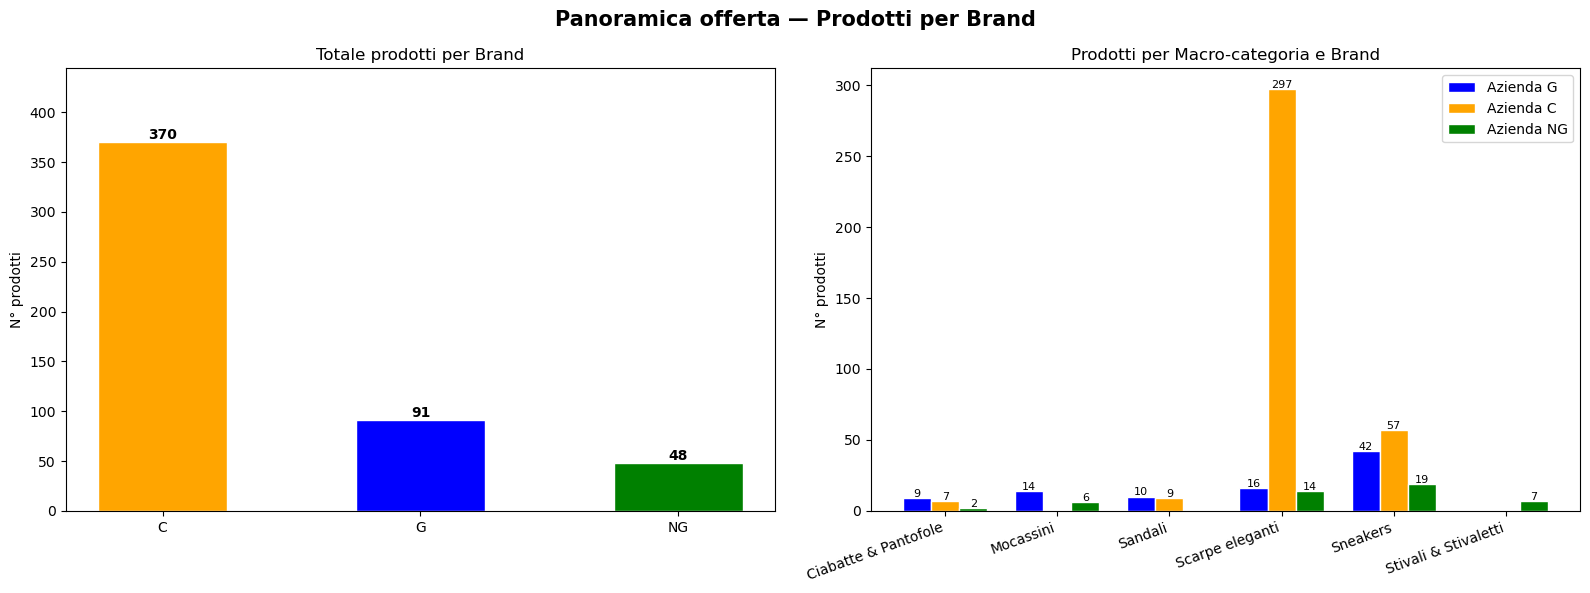


--- Tabella riepilogativa ---
Brand                   C   G  NG
Macro_categoria                  
Ciabatte & Pantofole    7   9   2
Mocassini               0  14   6
Sandali                 9  10   0
Scarpe eleganti       297  16  14
Sneakers               57  42  19
Stivali & Stivaletti    0   0   7


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Panoramica offerta — Prodotti per Brand", 
             fontsize=15, fontweight="bold")

# ── Grafico 1: totale prodotti per brand ──────────────────
tot_brand = df_unificato.groupby("Brand")["Scarpe"].count()
bars = axes[0].bar(tot_brand.index, tot_brand.values,
                   color=[COLORI[b] for b in tot_brand.index],
                   edgecolor="white", width=0.5)
axes[0].set_title("Totale prodotti per Brand")
axes[0].set_ylabel("N° prodotti")
axes[0].set_ylim(0, tot_brand.max() * 1.2)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(int(bar.get_height())), ha="center", fontweight="bold")

# ── Grafico 2: prodotti per brand e macro-categoria ───────
pivot = df_unificato.groupby(["Macro_categoria", "Brand"])["Scarpe"].count().unstack("Brand").fillna(0)
x= np.arange(len(pivot))
width = 0.25

for i, brand in enumerate(["G", "C", "NG"]):
    if brand in pivot.columns:
        bars2 = axes[1].bar(x + i * width, pivot[brand], width,
                            label=f"Azienda {brand}",
                            color=COLORI[brand], edgecolor="white")
        for bar in bars2:
            if bar.get_height() > 0:
                axes[1].text(bar.get_x() + bar.get_width()/2,
                             bar.get_height() + 1,
                             str(int(bar.get_height())),
                             ha="center", fontsize=8)

axes[1].set_title("Prodotti per Macro-categoria e Brand")
axes[1].set_ylabel("N° prodotti")
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(pivot.index, rotation=20, ha="right")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n--- Tabella riepilogativa ---")
print(pivot.fillna(0).astype(int).to_string())

---
## 4. Analisi dei Prezzi per Brand e Categoria

Confrontiamo il posizionamento di prezzo dei tre brand su due livelli:
- **Prezzo medio generale** per brand, con le barre di errore che indicano l'intervallo min/max dell'intera gamma
- **Prezzo medio per macro-categoria**, per capire dove ogni brand compete realmente in termini di fascia di mercato

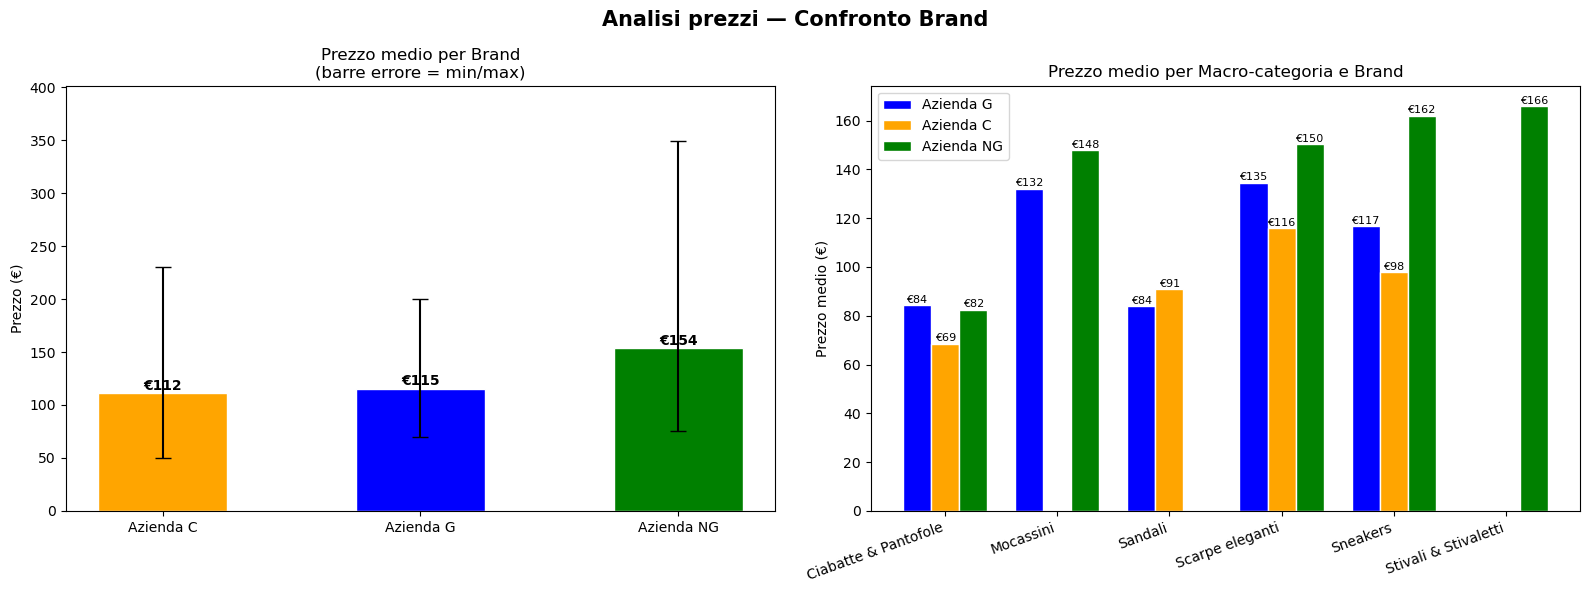


--- Tabella prezzi medi per macro-categoria ---
Brand                      C       G      NG
Macro_categoria                             
Ciabatte & Pantofole   68.55   84.34   82.45
Mocassini                  -  132.06  147.83
Sandali                90.99    83.9       -
Scarpe eleganti       115.84   134.6  150.29
Sneakers               97.94  116.69  161.92
Stivali & Stivaletti       -       -   166.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Analisi prezzi — Confronto Brand", 
             fontsize=15, fontweight="bold")

# ── Grafico 1: prezzo medio per brand ────────────────────
stats_brand = df_unificato.groupby("Brand")["Prezzo_reale"].agg(
    Media="mean", Minimo="min", Massimo="max"
).round(2)

x     = np.arange(len(stats_brand))
bars  = axes[0].bar(x, stats_brand["Media"],
                    color=[COLORI[b] for b in stats_brand.index],
                    edgecolor="white", width=0.5)

# Barre di errore min/max
axes[0].errorbar(x, stats_brand["Media"],
                 yerr=[stats_brand["Media"] - stats_brand["Minimo"],
                       stats_brand["Massimo"] - stats_brand["Media"]],
                 fmt="none", color="black", capsize=6, linewidth=1.5)

axes[0].set_title("Prezzo medio per Brand\n(barre errore = min/max)")
axes[0].set_ylabel("Prezzo (€)")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"Azienda {b}" for b in stats_brand.index])
axes[0].set_ylim(0, stats_brand["Massimo"].max() * 1.15)

for bar, (_, row) in zip(bars, stats_brand.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'€{row["Media"]:.0f}', ha="center", fontweight="bold")

# ── Grafico 2: prezzo medio per macro-categoria e brand ──
pivot_prezzi = df_unificato.groupby(
    ["Macro_categoria", "Brand"])["Prezzo_reale"].mean().unstack("Brand").round(2)

x2    = np.arange(len(pivot_prezzi))
width = 0.25

for i, brand in enumerate(["G", "C", "NG"]):
    if brand in pivot_prezzi.columns:
        vals = pivot_prezzi[brand].fillna(0)
        bars2 = axes[1].bar(x2 + i * width, vals, width,
                            label=f"Azienda {brand}",
                            color=COLORI[brand], edgecolor="white")
        for bar in bars2:
            if bar.get_height() > 0:
                axes[1].text(bar.get_x() + bar.get_width()/2,
                             bar.get_height() + 1,
                             f'€{bar.get_height():.0f}',
                             ha="center", fontsize=8)

axes[1].set_title("Prezzo medio per Macro-categoria e Brand")
axes[1].set_ylabel("Prezzo medio (€)")
axes[1].set_xticks(x2 + width)
axes[1].set_xticklabels(pivot_prezzi.index, rotation=20, ha="right")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n--- Tabella prezzi medi per macro-categoria ---")
print(pivot_prezzi.fillna("-").to_string())

---
## 5. Gap di Offerta — Categorie Presenti e Assenti

La heatmap evidenzia in modo immediato quali macro-categorie sono presidiate da ciascun brand e quali invece risultano scoperte. Le celle con `—` indicano un'assenza totale in quella categoria, rappresentando sia un potenziale gap competitivo per chi non c'è, sia una nicchia protetta per chi la presidia.

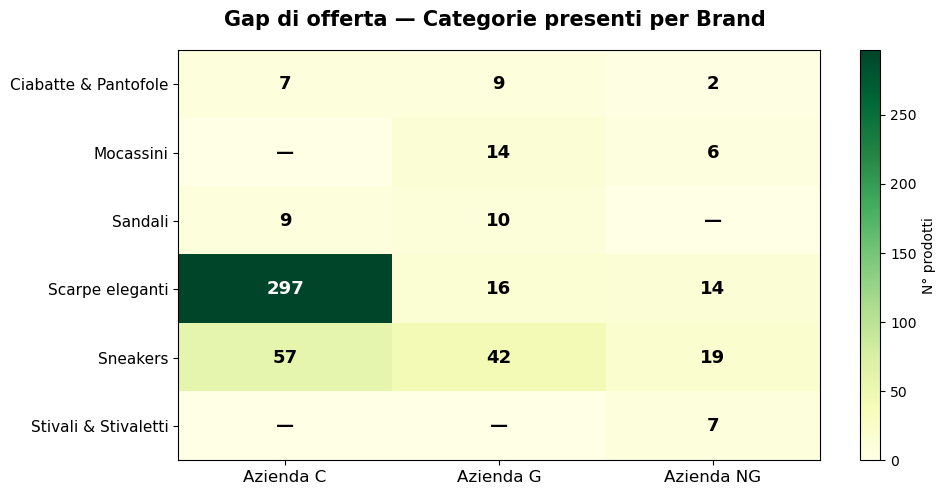

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Gap di offerta — Categorie presenti per Brand", 
             fontsize=15, fontweight="bold")

# Conta prodotti per brand e macro-categoria
pivot_gap = df_unificato.groupby(
    ["Macro_categoria", "Brand"])["Scarpe"].count().unstack("Brand").fillna(0)

# Heatmap manuale con colori
im = ax.imshow(pivot_gap.values, cmap="YlGn", aspect="auto")

ax.set_xticks(range(len(pivot_gap.columns)))
ax.set_xticklabels([f"Azienda {b}" for b in pivot_gap.columns], fontsize=12)
ax.set_yticks(range(len(pivot_gap.index)))
ax.set_yticklabels(pivot_gap.index, fontsize=11)

# Valori nelle celle
for i in range(len(pivot_gap.index)):
    for j in range(len(pivot_gap.columns)):
        val = int(pivot_gap.values[i, j])
        testo = str(val) if val > 0 else "—"
        colore = "white" if val > 100 else "black"
        ax.text(j, i, testo, ha="center", va="center",
                fontsize=13, fontweight="bold", color=colore)

plt.colorbar(im, ax=ax, label="N° prodotti")
plt.tight_layout()
plt.show()

---
## 6. Analisi delle Politiche di Sconto su Piattaforma Z

La piattaforma multimarca Z ci fornisce una visione esterna delle strategie promozionali dei brand. Analizziamo la percentuale di prodotti attualmente in sconto e l'entità media del ribasso, due indicatori chiave della pressione promozionale esercitata su ciascun brand.

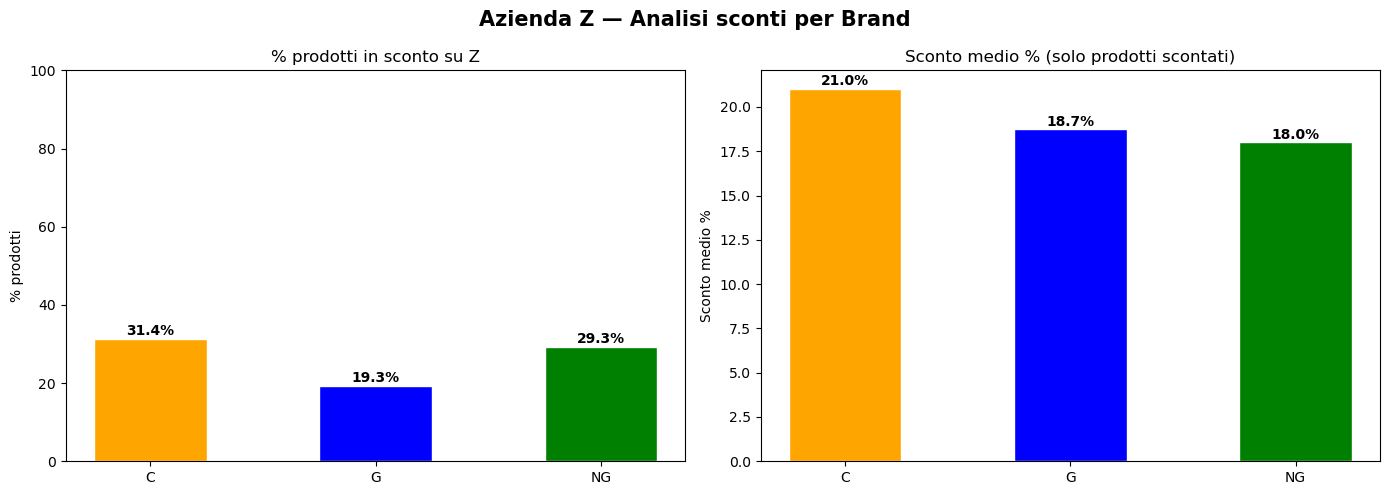


--- Riepilogo sconti Azienda Z ---
       N prodotti  In sconto % in sconto  Sconto medio € Sconto medio %
Brand                                                                  
C             204         64       31.4%            8.50           6.6%
G             477         92       19.3%            4.53           3.6%
NG             58         17       29.3%            9.36           5.3%


In [8]:
df_Z_sconto = df_Z[df_Z["In sconto"] == True].copy()
df_Z_sconto["Sconto_€"] = df_Z["Prezzo reale"] - df_Z["Prezzo scontato"]
df_Z_sconto["Sconto_%"] = (df_Z_sconto["Sconto_€"] / df_Z["Prezzo reale"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Azienda Z — Analisi sconti per Brand", 
             fontsize=15, fontweight="bold")

# ── Grafico 1: % prodotti in sconto ──────────────────────
pct_sconto = df_Z.groupby("Brand")["In sconto"].mean() * 100
bars = axes[0].bar(pct_sconto.index, pct_sconto.values,
                   color=[COLORI[b.replace("Azienda ","")] for b in pct_sconto.index],
                   edgecolor="white", width=0.5)
axes[0].set_title("% prodotti in sconto su Z")
axes[0].set_ylabel("% prodotti")
axes[0].set_ylim(0, 100)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}%', ha="center", fontweight="bold")

# ── Grafico 2: sconto medio % per brand ──────────────────
sconto_medio = df_Z_sconto.groupby("Brand")["Sconto_%"].mean()
bars2 = axes[1].bar(sconto_medio.index, sconto_medio.values,
                    color=[COLORI[b.replace("Azienda ","")] for b in sconto_medio.index],
                    edgecolor="white", width=0.5)
axes[1].set_title("Sconto medio % (solo prodotti scontati)")
axes[1].set_ylabel("Sconto medio %")
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{bar.get_height():.1f}%', ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print("\n--- Riepilogo sconti Azienda Z ---")
print(df_Z.groupby("Brand").apply(lambda g: pd.Series({
    "N prodotti":    len(g),
    "In sconto":     g["In sconto"].sum(),
    "% in sconto":   f'{g["In sconto"].mean()*100:.1f}%',
    "Sconto medio €": round((g["Prezzo reale"]-g["Prezzo scontato"]).mean(), 2),
    "Sconto medio %": f'{((g["Prezzo reale"]-g["Prezzo scontato"])/g["Prezzo reale"]*100).mean():.1f}%'
}), include_groups=False).to_string())

---
## 7. Distribuzione dei Prezzi Reali su Piattaforma Z

Il boxplot mostra la distribuzione completa dei prezzi di listino per brand sulla piattaforma Z. Oltre alla mediana e all'intervallo interquartile, i punti fuori dai baffi rappresentano prodotti anomali (outlier) — modelli con prezzi significativamente distanti dalla gamma core del brand.

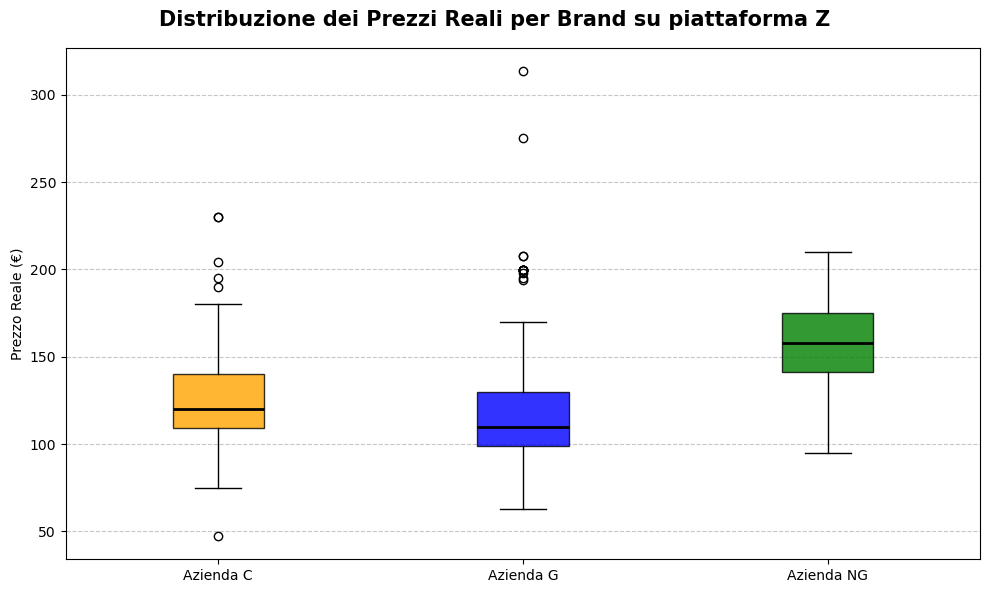

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Distribuzione dei Prezzi Reali per Brand su piattaforma Z", fontsize=15, fontweight="bold")

brands = ["C", "G", "NG"]
# Prepariamo una lista di liste con i prezzi per ciascun brand
dati_prezzi = [df_Z[df_Z["Brand"] == b]["Prezzo reale"].dropna() for b in brands]

# Creiamo il boxplot (Aggiornato con tick_labels per Matplotlib 3.9+)
bplot = ax.boxplot(dati_prezzi, patch_artist=True, 
                   tick_labels=[f"Azienda {b}" for b in brands],
                   medianprops=dict(color="black", linewidth=2))

# Coloriamo le scatole con i colori aziendali
for patch, color in zip(bplot['boxes'], [COLORI[b] for b in brands]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_ylabel("Prezzo Reale (€)")
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Insight sulla Distribuzione dei Prezzi

Il grafico a scatola e baffi (Boxplot) ci svela le reali strategie di posizionamento dei tre brand:

* **Azienda C (Arancione) — Mass-Market Elastico:** La mediana si assesta intorno ai 120€, con il 50% dell'offerta (la scatola) concentrato tra i 110€ e i 140€. C'è una buona flessibilità: coprono dai 75€ fino a superare i 180€, con alcune eccezioni (outlier) sia verso il basso che verso l'alto.
* **Azienda G (Blu) — Core Concentrato e Linee Prestige:** Ha il *core business* più compatto e focalizzato (scatola stretta) intorno ai 100€-130€, con una mediana leggermente inferiore ad Azienda C. La vera anomalia strategica è rappresentata dai forti **outlier superiori** (i cerchi oltre i 250€, con un picco oltre i 300€). Questo indica la presenza di una linea premium, di edizioni limitate o di una specifica nicchia di lusso che si distacca completamente dal resto del catalogo.
* **Azienda NG (Verde) — Premium Rigoroso:** Il posizionamento alto è netto. L'intera scatola centrale (50% dei prodotti) parte da dove finiscono i prezzi medi degli altri brand (140€ - 175€). L'assenza totale di outlier denota una politica di marchio molto rigida e coerente: non scendono a compromessi con linee economiche per fare volume, mantenendo intatta la percezione di esclusività.

---
## 8. Sconti per Macro-categoria e Brand

Scendendo nel dettaglio, analizziamo la percentuale di prodotti in sconto per ogni macro-categoria. Questo rivela quali segmenti di prodotto vengono utilizzati come leva promozionale e dove invece i brand proteggono maggiormente il prezzo pieno.

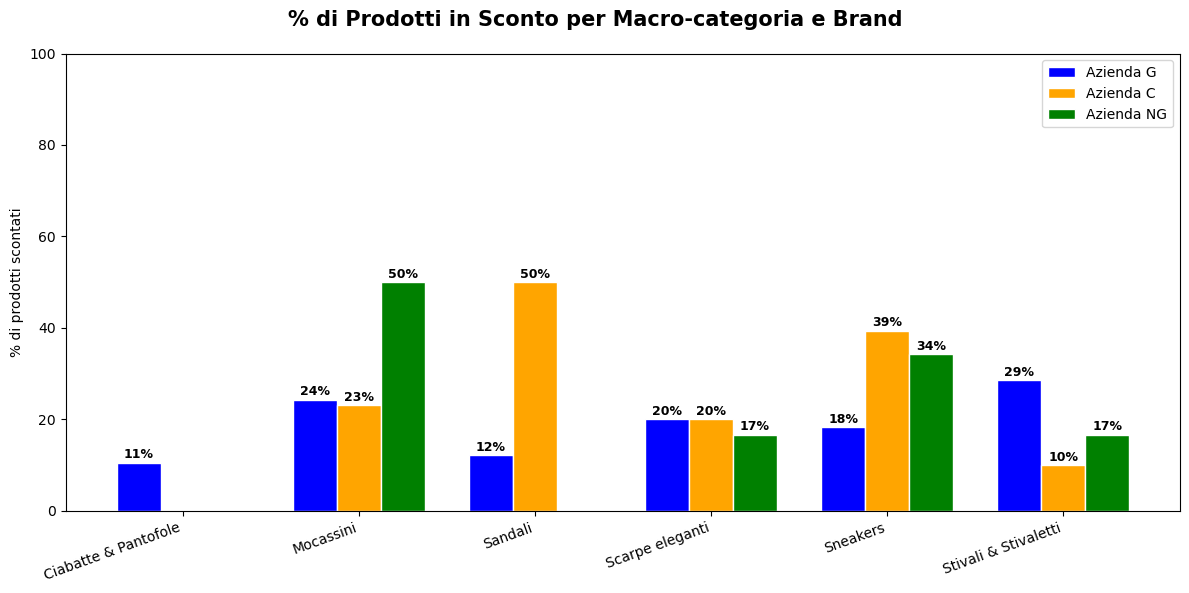

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("% di Prodotti in Sconto per Macro-categoria e Brand", fontsize=15, fontweight="bold")

# Calcoliamo la media booleana (True = 1, False = 0) moltiplicata per 100 per avere la %
sconti_cat = df_Z.groupby(["Macro_categoria", "Brand"])["In sconto"].mean().unstack("Brand").fillna(0) * 100

x = np.arange(len(sconti_cat))
width = 0.25

for i, brand in enumerate(["G", "C", "NG"]):
    if brand in sconti_cat.columns:
        bars = ax.bar(x + i * width, sconti_cat[brand], width,
                      label=f"Azienda {brand}", color=COLORI[brand], edgecolor="white")
        for bar in bars:
            altezza = bar.get_height()
            if altezza > 0:
                ax.text(bar.get_x() + bar.get_width()/2, altezza + 1,
                        f"{altezza:.0f}%", ha="center", fontsize=9, fontweight="bold")

ax.set_ylabel("% di prodotti scontati")
ax.set_xticks(x + width)
ax.set_xticklabels(sconti_cat.index, rotation=20, ha="right")
ax.legend()
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

---
## 9. (Bonus) Varietà Cromatica dell'Offerta

Come analisi supplementare, utilizziamo i dati della piattaforma Z per confrontare la varietà di colori disponibili per brand e categoria. 
La ricchezza cromatica è un indicatore indiretto della profondità dell'offerta e può influenzare significativamente la conversione negli acquisti online, dove il colore è spesso il primo filtro applicato dal consumatore.

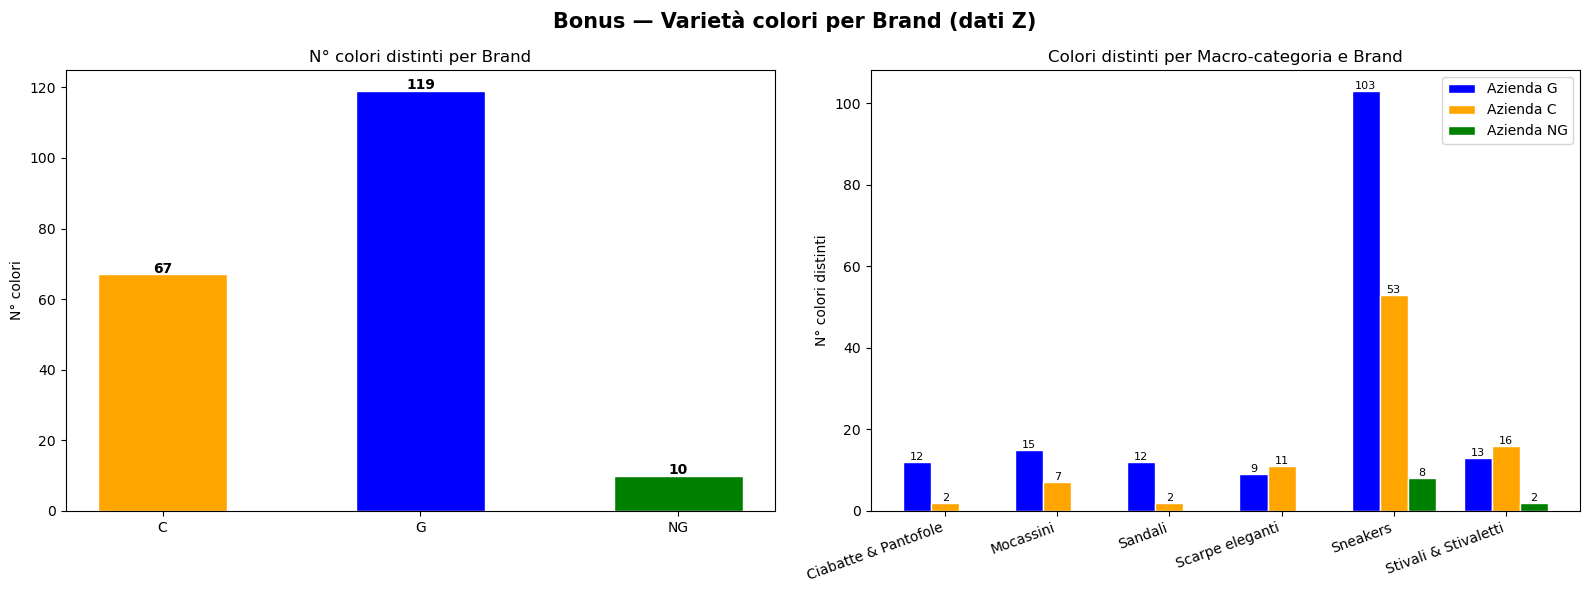

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Bonus — Varietà colori per Brand (dati Z)", 
             fontsize=15, fontweight="bold")

# ── Grafico 1: colori totali per brand ───────────────────
colori_tot = df_Z.groupby("Brand")["Dettaglio/Colore"].nunique()
# I brand in colori_tot.index sono "C", "G", "NG", quindi COLORI[b] funziona direttamente
bars = axes[0].bar(colori_tot.index, colori_tot.values,
                   color=[COLORI[b] for b in colori_tot.index],
                   edgecolor="white", width=0.5)
axes[0].set_title("N° colori distinti per Brand")
axes[0].set_ylabel("N° colori")
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(int(bar.get_height())), ha="center", fontweight="bold")

# ── Grafico 2: colori per macro-categoria e brand ────────
colori_cat = df_Z.groupby(
    ["Brand", "Macro_categoria"])["Dettaglio/Colore"].nunique().unstack("Brand").fillna(0)

x     = np.arange(len(colori_cat))
width = 0.25

# Cerchiamo i valori esatti presenti nel dataframe ("G", "C", "NG")
for i, brand in enumerate(["G", "C", "NG"]):
    if brand in colori_cat.columns:
        bars2 = axes[1].bar(x + i * width, colori_cat[brand], width,
                            label=f"Azienda {brand}",  # Aggiungiamo 'Azienda' per la legenda
                            color=COLORI[brand], edgecolor="white")
        for bar in bars2:
            if bar.get_height() > 0:
                axes[1].text(bar.get_x() + bar.get_width()/2,
                             bar.get_height() + 0.5,
                             str(int(bar.get_height())),
                             ha="center", fontsize=8)

axes[1].set_title("Colori distinti per Macro-categoria e Brand")
axes[1].set_ylabel("N° colori distinti")
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(colori_cat.index, rotation=20, ha="right")
axes[1].legend()

plt.tight_layout()
plt.show()

### Insight sulle Politiche Promozionali per Categoria

Disaggregando i dati promozionali per singola macro-categoria, le strategie di *pricing* dei tre brand si delineano con maggiore precisione, rivelando approcci fortemente legati alla stagionalità e allo smaltimento del magazzino:

* **Azienda C (Arancione) — Liquidazione Mirata:** L'alta percentuale di sconti generali del brand è in realtà trainata da specifiche categorie. Ben il **50% dei Sandali** e il **39% delle Sneakers** sono in saldo. Questo denota un'aggressiva operazione di liquidazione delle giacenze (probabilmente di fine stagione estiva) e una forte spinta sui volumi del casual. Sul loro vero *core business*, le Scarpe Eleganti, si allineano invece al mercato con un più fisiologico 20%.
* **Azienda NG (Verde) — Promozioni d'Ingresso:** Nonostante il posizionamento premium (confermato dalla bassissima percentuale di sconti su Scarpe Eleganti e Stivali, sotto il 17%), l'azienda sconta clamorosamente il **50% dei Mocassini** e il **34% delle Sneakers**. Questa anomalia suggerisce una strategia di "entry-level discount": usare queste categorie come prodotto-civetta per abbassare la barriera d'ingresso e far provare il brand a nuovi clienti.
* **Azienda G (Blu) — Coerenza e Stabilità:** Conferma l'approccio più bilanciato e conservativo. Le percentuali di sconto sono ben distribuite (tra l'11% e il 24%) su quasi tutto il catalogo, proteggendo la marginalità. L'unico vero picco promozionale si registra su **Stivali & Stivaletti (29%)**, indicando una mossa tattica per spingere questa categoria specifica in un segmento altamente competitivo.

---
## 10. Confronto Canale: Sito Ufficiale vs Piattaforma Z

Per i modelli presenti contemporaneamente sul sito ufficiale e sulla piattaforma Z, confrontiamo il prezzo medio nei due canali. Questa analisi rivela l'esistenza di potenziali **conflitti di canale**: situazioni in cui il retailer offre lo stesso prodotto a un prezzo inferiore rispetto all'e-commerce diretto, cannibalizzando le vendite D2C del brand.

In [12]:
# 1. Prepariamo il dataset dei siti ufficiali prendendo le colonne necessarie
df_siti_confronto = df_unificato[['Brand', 'Scarpe', 'Prezzo_reale']].copy()
df_siti_confronto = df_siti_confronto.rename(columns={'Prezzo_reale': 'Prezzo_Sito_Ufficiale'})

# Calcoliamo il prezzo medio ufficiale per brand/modello se ci sono più inserzioni dello stesso modello
df_siti_unique = df_siti_confronto.groupby(['Brand', 'Scarpe'], as_index=False)['Prezzo_Sito_Ufficiale'].mean()

# 2. Eseguiamo l'Inner Join con il dataset di Z
# Questo terrà SOLO i modelli che hanno una corrispondenza esatta di Brand e Nome Scarpa
df_channel_gap = pd.merge(df_Z, df_siti_unique, on=['Brand', 'Scarpe'], how='inner')

# 3. Calcoliamo la differenza assoluta e percentuale (Prezzo scontato Z vs Sito Ufficiale)
df_channel_gap['Price_Delta_€'] = df_channel_gap['Prezzo scontato'] - df_channel_gap['Prezzo_Sito_Ufficiale']
df_channel_gap['Price_Delta_%'] = (df_channel_gap['Price_Delta_€'] / df_channel_gap['Prezzo_Sito_Ufficiale']) * 100

print(f"Numero di modelli perfettamente matchati tra canali: {df_channel_gap['Scarpe'].nunique()}")
display(df_channel_gap[['Brand', 'Scarpe', 'Prezzo_Sito_Ufficiale', 'Prezzo reale', 'Prezzo scontato', 'Price_Delta_€']].head())

Numero di modelli perfettamente matchati tra canali: 20


,Brand,Scarpe,Prezzo_Sito_Ufficiale,Prezzo reale,Prezzo scontato,Price_Delta_€
0,C,Lockford Lace,90.0,89.95,89.95,-0.05
1,C,Wallabee,145.5,111.99,111.99,-33.51
2,C,Wallabee,145.5,119.99,89.99,-55.51
3,C,Wallabee,145.5,149.99,104.99,-40.51
4,C,Wallabee,145.5,119.99,119.99,-25.51


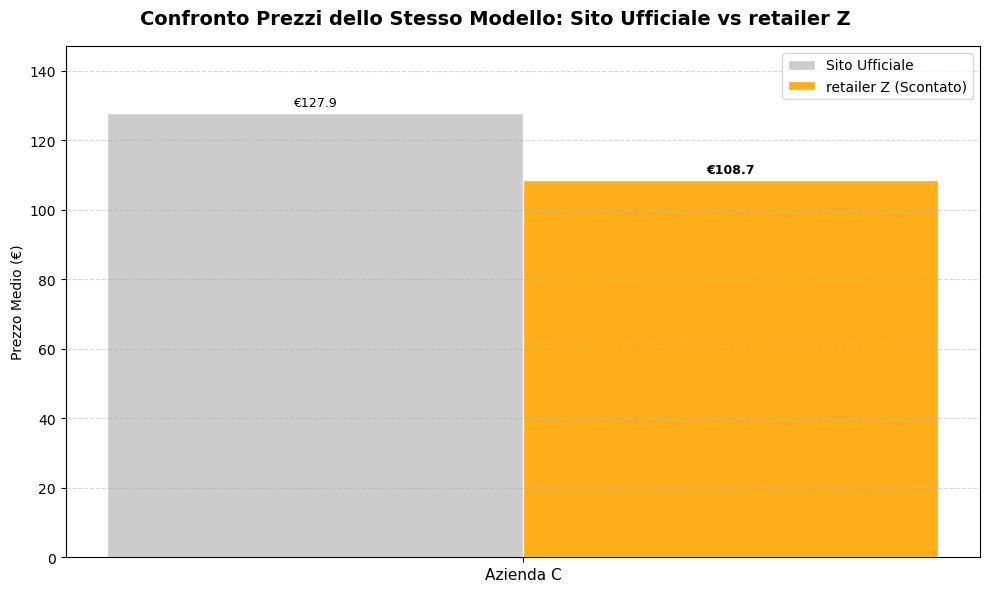

--- Delta medio di canale (Z vs Sito Ufficiale) ---
Azienda C: retailer Z è più conveniente di €19.22 (-15.0%) rispetto al sito ufficiale.


In [13]:
# Raggruppiamo per Brand i modelli matchati per calcolare i prezzi medi nei due canali
piv_confronto = df_channel_gap.groupby('Brand')[['Prezzo_Sito_Ufficiale', 'Prezzo scontato']].mean()

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Confronto Prezzi dello Stesso Modello: Sito Ufficiale vs retailer Z", fontsize=14, fontweight="bold")

x = np.arange(len(piv_confronto))
width = 0.35

# Barre Sito Ufficiale (Grigio chiaro per fare contrasto con l'identità del brand su Z)
bars_sito = ax.bar(x - width/2, piv_confronto['Prezzo_Sito_Ufficiale'], width, 
                   label='Sito Ufficiale', color='#CCCCCC', edgecolor='white')

# Barre Z (Utilizziamo il colore specifico del Brand)
colori_barre_z = [COLORI[b] for b in piv_confronto.index]
bars_z = ax.bar(x + width/2, piv_confronto['Prezzo scontato'], width, 
                     label='retailer Z (Scontato)', color=colori_barre_z, edgecolor='white', alpha=0.9)

# Aggiungiamo i valori sopra le barre
for bar in bars_sito:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"€{bar.get_height():.1f}", ha='center', fontsize=9)
for bar in bars_z:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"€{bar.get_height():.1f}", ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Prezzo Medio (€)')
ax.set_xticks(x)
ax.set_xticklabels([f"Azienda {b}" for b in piv_confronto.index], fontsize=11)
ax.set_ylim(0, piv_confronto.values.max() * 1.15)
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Calcoliamo lo sconto medio reale che l'utente trova su Z rispetto al cartellino ufficiale
print("--- Delta medio di canale (Z vs Sito Ufficiale) ---")
for brand in piv_confronto.index:
    diff = piv_confronto.loc[brand, 'Prezzo scontato'] - piv_confronto.loc[brand, 'Prezzo_Sito_Ufficiale']
    perc = (diff / piv_confronto.loc[brand, 'Prezzo_Sito_Ufficiale']) * 100
    print(f"Azienda {brand}: retailer Z è più conveniente di €{abs(diff):.2f} ({perc:.1f}%) rispetto al sito ufficiale.")

### Insight sull'Analisi di Canale: Il Rischio Cannibalizzazione

Incrociando i cataloghi per individuare i modelli venduti in contemporanea su entrambi i canali, è emersa una sovrapposizione rilevante esclusivamente per l'Azienda C. L'analisi dei prezzi su questo campione svela un evidente problema di **Channel Conflict (Conflitto di Canale)**:

* **Delta Competitivo:** Lo stesso modello risulta mediamente più conveniente di **€19.22 (-15.0%)** sulla piattaforma multimarca Z rispetto all'e-commerce ufficiale.

**Implicazioni Strategiche:** L'Azienda C sta essenzialmente facendo competizione a sé stessa. Il consumatore moderno, abituato a comparare i prezzi, tenderà a finalizzare l'acquisto sul portale Z. Questo sposta i volumi di vendita dal canale diretto (D2C), dove l'azienda trattiene l'intero margine, verso il canale wholesale, che garantisce marginalità nette drasticamente inferiori. 
L'assenza di match diretti per le aziende G e NG suggerisce invece che questi brand applichino una rigorosa differenziazione dell'assortimento (es. nomi diversi o linee esclusive per i rivenditori) proprio per proteggere l'integrità del proprio listino ufficiale e la percezione premium del marchio.

---
## 12. Sintesi Strategica

L'esplorazione dei dati ha permesso di estrarre insight chiari e azionabili. Le raccomandazioni dettagliate per il nostro brand team, basate sulle metriche appena visualizzate, sono state strutturate per essere portate in presentazione al CEO, al fine di ottimizzare la posizione competitiva nella prossima stagione.

## 📊 Executive Summary e Posizionamento Competitivo

Dall'analisi delle collezioni stagionali e delle strategie di pricing, emergono tre identità di mercato ben distinte:

* **Azienda C (Leader di Volume):** Domina incontrastata per ampiezza dell'offerta (370 prodotti), concentrandosi quasi esclusivamente sulla macro-categoria *Scarpe eleganti*. Mantiene un prezzo medio altamente competitivo (**€112**), puntando su una strategia di mass-market.
* **Azienda NG (Premium Niche):** Offerta molto selezionata (48 prodotti) con il prezzo medio più alto del panel (**€154**). Presidia il mercato premium e detiene il monopolio assoluto nella categoria *Stivali & Stivaletti*, non presidiando però il segmento estivo (sandali/ciabatte).
* **Azienda G (Generalista Bilanciato):** Rappresenta il perfetto *middle-ground*. Con 91 prodotti, offre il catalogo più omogeneo, coprendo quasi tutte le categorie. Si posiziona su una fascia di prezzo media (**€115**), vicina all'Azienda C ma con una proposta molto più versatile.

---
## 🏷️ Dinamiche di Prezzo e Politiche di Sconto (Piattaforma Z)

L'analisi dell'aggregatore multimarca ha rivelato approcci promozionali diametralmente opposti, fondamentali per l'acquisizione clienti e la percezione del brand:

* **Aggressività Promozionale (Azienda C):** Adotta una strategia *push* marcata, con quasi un terzo del catalogo in saldo (**31.4%**) e lo sconto medio più profondo (**21.0%**). Questo favorisce alti volumi di vendita ma rischia di erodere il posizionamento del marchio.
* **Protezione del Valore (Azienda G):** Applica un approccio conservativo e focalizzato sulla profittabilità. Solo il **19.3%** dei prodotti è in sconto, con una percentuale di taglio prezzo più contenuta (**18.7%**).
* **Sconti Tattici (Azienda NG):** Pur essendo un brand premium, utilizza la leva dello sconto sul **29.3%** della sua linea, con un ribasso medio del **18.0%**.

---
## 🎯 Conclusioni e Raccomandazioni Strategiche

Sulla base dei dati emersi, si sottopongono al CEO le seguenti direttive per la prossima stagione:

**Azienda G**
1.  **Sviluppo Nuove Linee:** Esiste un evidente "vuoto di mercato" nella categoria *Stivali & Stivaletti*, attualmente monopolizzata dall'Azienda NG a prezzi premium (€166). Inserire una linea a prezzo medio (€120–€130) permetterebbe di aggredire una grossa fetta di clientela lasciata scoperta.
2.  **Spinta Marketing sui Mocassini:** Azienda G è attualmente leader in questa categoria (14 modelli contro 0 del competitor diretto C). È un vantaggio competitivo netto da massimizzare con campagne di comunicazione mirate.
3.  **Mantenimento Margini:** Si consiglia di continuare con l'attuale politica di sconti contenuti (sotto il 20%). Questo protegge la *brand equity* ed evita una pericolosa guerra dei prezzi al ribasso con l'Azienda C.
4.  **Valorizzare la Varietà Cromatica:** L'analisi su piattaforma Z evidenzia che G offre 119 colorazioni distinte (vs 67 di C e 10 di NG), con una concentrazione di 103 varianti nelle sole Sneakers. Questa ricchezza va comunicata esplicitamente   come punto di differenziazione, specialmente nei canali digitali dove la scelta del colore è leva decisiva di conversione.  

**Azienda C**
1.  **Diversificazione del Catalogo:** L'eccessiva dipendenza dalle *Scarpe eleganti* (297 modelli su 370) espone a forti rischi se i trend di mercato dovessero spostarsi sul casual. È prioritario espandere l'offerta verso categorie scoperte come *Mocassini* e *Stivali*.
2.  **Revisione Politica Promozionale:** Si consiglia di ridurre progressivamente l'aggressività degli sconti (attualmente oltre il 30% del catalogo è tagliato del 21%). Il rischio è abituare il consumatore ad acquistare esclusivamente durante i saldi, distruggendo la marginalità a lungo termine.

**Azienda NG**
1.  **Destagionalizzazione dell'Offerta:** Il catalogo attuale è fortemente sbilanciato sui mesi freddi e intermedi. Introdurre una *capsule collection* estiva di fascia alta (Sandali/Ciabatte) permetterebbe di mantenere i flussi di cassa costanti durante tutto l'anno.
2.  **Espansione Orizzontale nel Casual:** Essendo leader sulla fascia premium di Stivali e Scarpe Eleganti, si consiglia un cauto ampliamento della linea *Sneakers* (attualmente 19 modelli) per incrementare i volumi di vendita intercettando il trend dell'abbigliamento daily-wear di lusso.